In [1]:
dataset = '1919_SYN_30'

In [2]:
import os
import numpy as np
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, precision_score, recall_score, accuracy_score, roc_curve, auc, f1_score
from sklearn.metrics import precision_recall_curve
from sklearn.preprocessing import LabelEncoder
from ultralytics import YOLO
from sklearn.model_selection import train_test_split
import cv2
import seaborn as sns

In [3]:
train_dir = str('DS_REAL_SPLITED_' + dataset)

model = YOLO("yolo12n-cls.yaml")

model.train(data=train_dir, epochs=300, imgsz=64, project='YOLO12-RESULTS', name=dataset)

YOLO12n-cls summary: 152 layers, 1,820,976 parameters, 1,820,976 gradients, 3.7 GFLOPs
New https://pypi.org/project/ultralytics/8.3.230 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.169 🚀 Python-3.11.0rc1 torch-2.0.1+cu118 CUDA:0 (NVIDIA GeForce RTX 4090, 24564MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=DS_REAL_SPLITED_1919_SYN_30, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=300, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=64, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo12n-cls.

/usr/local/lib/python3.11/dist-packages/torch/nn/modules/conv.py:459: UserWarning: Applied workaround for CuDNN issue, install nvrtc.so (Triggered internally at ../aten/src/ATen/native/cudnn/Conv_v8.cpp:80.)
  return F.conv2d(input, weight, bias, self.stride,


AMP: checks passed ✅
train: Fast image access ✅ (ping: 7.2±0.6 ms, read: 3.3±0.7 MB/s, size: 37.4 KB)


train: Scanning /tf/2025/SEEDS/DS_REAL_SPLITED_1919_SYN_30/train... 4550 images, 0 corrupt: 100%|██████████| 4550/4550 [


train: New cache created: /tf/2025/SEEDS/DS_REAL_SPLITED_1919_SYN_30/train.cache
val: Fast image access ✅ (ping: 9.0±0.6 ms, read: 2.0±0.2 MB/s, size: 34.0 KB)


...

                   all      0.777      0.988

300 epochs completed in 1.467 hours.


Optimizer stripped from YOLO12-RESULTS/1919_SYN_30/weights/last.pt, 3.7MB
Optimizer stripped from YOLO12-RESULTS/1919_SYN_30/weights/best.pt, 3.7MB

Validating YOLO12-RESULTS/1919_SYN_30/weights/best.pt...
Ultralytics 8.3.169 🚀 Python-3.11.0rc1 torch-2.0.1+cu118 CUDA:0 (NVIDIA GeForce RTX 4090, 24564MiB)
YOLO12n-cls summary (fused): 94 layers, 1,722,450 parameters, 0 gradients, 3.5 GFLOPs
train: /tf/2025/SEEDS/DS_REAL_SPLITED_1919_SYN_30/train... found 4550 images in 10 classes ✅ 
val: /tf/2025/SEEDS/DS_REAL_SPLITED_1919_SYN_30/val... found 750 images in 10 classes ✅ 
test: /tf/2025/SEEDS/DS_REAL_SPLITED_1919_SYN_30/test... found 750 images in 10 classes ✅ 


               classes   top1_acc   top5_acc: 100%|██████████| 24/24 [00:00<00:00, 63.27it/s]


                   all      0.777      0.988
Speed: 0.1ms preprocess, 0.2ms inference, 0.0ms loss, 0.0ms postprocess per image
Results saved to YOLO12-RESULTS/1919_SYN_30


ultralytics.utils.metrics.ClassifyMetrics object with attributes:

confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7f3518c34950>
curves: []
curves_results: []
fitness: 0.8826666474342346
keys: ['metrics/accuracy_top1', 'metrics/accuracy_top5']
results_dict: {'metrics/accuracy_top1': 0.7773333191871643, 'metrics/accuracy_top5': 0.9879999756813049, 'fitness': 0.8826666474342346}
save_dir: PosixPath('YOLO12-RESULTS/1919_SYN_30')
speed: {'preprocess': 0.051472489353424564, 'inference': 0.2484622973424848, 'loss': 0.00010649869606519738, 'postprocess': 0.00019086662602300444}
task: 'classify'
top1: 0.7773333191871643
top5: 0.9879999756813049

In [4]:
from pathlib import Path
from PIL import Image
from sklearn.metrics import classification_report

def avaliar_modelo(model, val_path, imgsz=64, verbose=False):

    val_path = Path(val_path)

    class_names = sorted([d.name for d in val_path.iterdir() if d.is_dir()])
    class_to_idx = {cls_name: idx for idx, cls_name in enumerate(class_names)}

    y_true = []
    y_pred = []

    for cls_name in class_names:
        cls_dir = val_path / cls_name
        label = class_to_idx[cls_name]

        for img_path in cls_dir.glob("*.*"):  # jpg, png, etc.
            try:
                img = Image.open(img_path).convert("RGB")
                results = model.predict(img, imgsz=imgsz, verbose=False)
                pred = int(results[0].probs.top1)

                y_true.append(label)
                y_pred.append(pred)

                if verbose:
                    print(f"Imagem: {img_path.name} | Real: {cls_name} | Previsto: {class_names[pred]}")

            except Exception as e:
                print(f"[ERRO] Falha ao processar {img_path.name}: {e}")

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    acc = accuracy_score(y_true, y_pred)
    report = classification_report(y_true, y_pred, target_names=class_names)

    print(f"\n🔍 Acurácia: {acc:.4f}")
    print(report)

    return y_true, y_pred, report

In [5]:
# Carregue seu modelo (pré-treinado ou treinado)
model = YOLO(str('YOLO12-RESULTS/' + dataset + '/weights/best.pt'))

# Caminho para pasta de validação
val_path = str('DS_REAL_SPLITED_' + dataset + '/test')

# Avaliação
y_true, y_pred, relatorio = avaliar_modelo(model, val_path, imgsz=64, verbose=False)



🔍 Acurácia: 0.7880
                   precision    recall  f1-score   support

      BULKCARRIER       0.71      0.55      0.62        75
    CONTAINERSHIP       0.83      0.87      0.85        75
     GENERALCARGO       0.64      0.63      0.63        75
OILPRODUCTSTANKER       0.61      0.41      0.49        75
   PASSENGERSSHIP       0.88      0.92      0.90        75
           TANKER       0.54      0.81      0.65        75
          TRAWLER       0.85      0.89      0.87        75
              TUG       0.93      0.93      0.93        75
  VEHICLESCARRIER       0.97      0.89      0.93        75
            YACHT       0.97      0.97      0.97        75

         accuracy                           0.79       750
        macro avg       0.79      0.79      0.78       750
     weighted avg       0.79      0.79      0.78       750



In [6]:
def plotar_metricas(y_true, y_pred):
    """
    Gera os gráficos de Acurácia, Precisão, Recall e a Matriz de Confusão.
    """
    # 1. Acurácia
    accuracy = accuracy_score(y_true, y_pred)

    # 2. Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)

    # 3. Precision
    precision = precision_score(y_true, y_pred, average='macro')

    # 4. Recall
    recall = recall_score(y_true, y_pred, average='macro')

    #5. F1-Score
    f1 = f1_score(y_true, y_pred, average='macro')

    # Plot 1: Gráfico de Acurácia, Precisão e Recall
    metrics = [accuracy, precision, recall, f1]
    metrics_names = ['Acurácia', 'Precisão', 'Recall', 'f1_score']

    plt.figure(figsize=(8, 6))
    plt.bar(metrics_names, metrics, color=['blue', 'green', 'orange', 'yellow'])
    plt.title('Acurácia, Precisão, Recall & F1')
    plt.ylim(0, 1)
    plt.ylabel('Valor')
    for i, value in enumerate(metrics):
        plt.text(i, value + 0.02, f'{value:.4f}', ha='center', va='bottom', fontsize=12)
    plt.show()

    # Plot 2: Matriz de Confusão
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap='Blues', xticklabels=np.arange(1, cm.shape[1] + 1), yticklabels=np.arange(1, cm.shape[0] + 1))
    plt.title('Matriz de Confusão')
    plt.xlabel('Predições')
    plt.ylabel('Verdadeiros')
    plt.show()

    print(f'Acurácia: {accuracy:.4f}')
    print(f'Precision: {precision:.4f}')
    print(f'Recall: {recall:.4f}')
    print(f'F1 Score: {f1:.4f}')
    print(f'Confusion Matrix:\n{cm}')

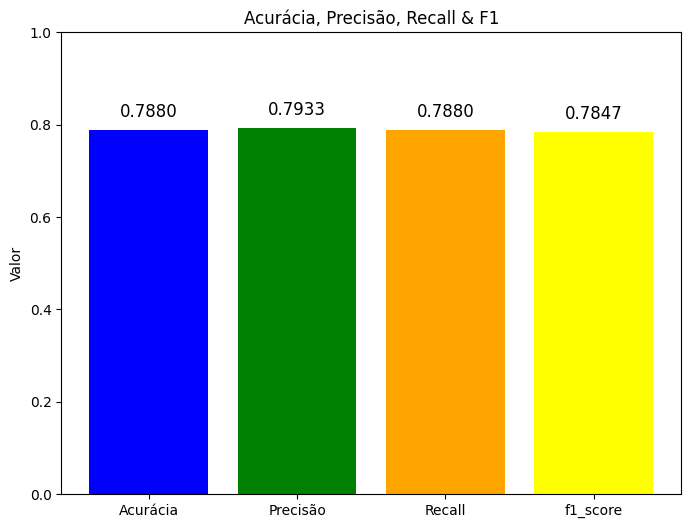

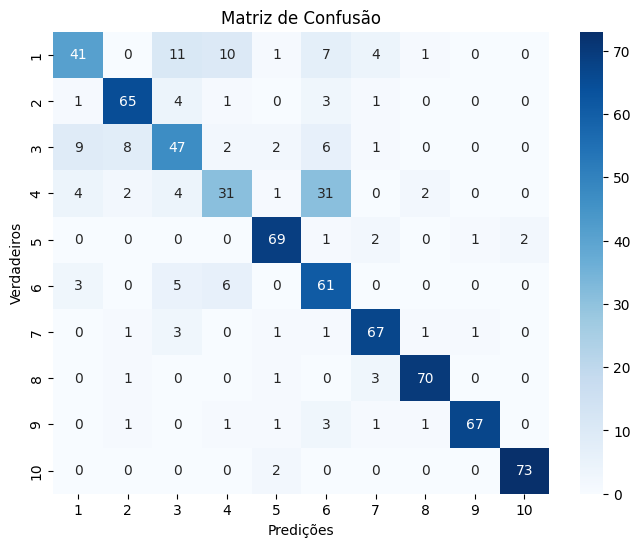

Acurácia: 0.7880
Precision: 0.7933
Recall: 0.7880
F1 Score: 0.7847
Confusion Matrix:
[[41  0 11 10  1  7  4  1  0  0]
 [ 1 65  4  1  0  3  1  0  0  0]
 [ 9  8 47  2  2  6  1  0  0  0]
 [ 4  2  4 31  1 31  0  2  0  0]
 [ 0  0  0  0 69  1  2  0  1  2]
 [ 3  0  5  6  0 61  0  0  0  0]
 [ 0  1  3  0  1  1 67  1  1  0]
 [ 0  1  0  0  1  0  3 70  0  0]
 [ 0  1  0  1  1  3  1  1 67  0]
 [ 0  0  0  0  2  0  0  0  0 73]]


In [7]:
%matplotlib inline
plotar_metricas(y_true, y_pred)